# EV Charging Station Analysis

## Hector Pena
## DSC 680
## Bellevue University

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [5]:
# Load the dataset
df = pd.read_csv('ev_charging_station_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date Range: {df["timestamp"].min()} to {df["timestamp"].max()}')

Dataset Shape: 1,317,750 rows x 33 columns
Date Range: 2025-07-01 00:00:00 to 2025-12-31 00:00:00


In [6]:
df.head()

,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01 00:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,5.08,2,none,False,False,0,1,7
1,2025-07-01 00:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.72,3,none,False,False,0,1,7
2,2025-07-01 01:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.68,1,none,False,False,1,1,7
3,2025-07-01 01:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.78,3,none,False,False,1,1,7
4,2025-07-01 02:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.69,1,none,False,False,2,1,7


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317750 entries, 0 to 1317749
Data columns (total 33 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   timestamp                  1317750 non-null  datetime64[ns]
 1   station_id                 1317750 non-null  object        
 2   station_name               1317750 non-null  object        
 3   network                    1317750 non-null  object        
 4   city                       1317750 non-null  object        
 5   state                      1317750 non-null  object        
 6   latitude                   1317750 non-null  float64       
 7   longitude                  1317750 non-null  float64       
 8   location_type              1317750 non-null  object        
 9   charger_type               1317750 non-null  object        
 10  power_output_kw            1317750 non-null  float64       
 11  amenities_nearby           1317750 no

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values found')

Missing Values Summary:
No missing values found


In [9]:
df.describe()

,timestamp,latitude,longitude,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,precipitation_mm,gas_price_per_gallon,traffic_congestion_index,hour_of_day,day_of_week,month
count,1317750,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06
mean,2025-09-30 12:00:00,3.744355e+01,-1.016788e+02,1.345880e+02,7.306667e+00,4.199560e+00,2.393753e+00,7.133538e-01,4.161674e-01,2.573585e+00,8.186490e+01,3.136559e-01,7.167426e+01,5.822979e-01,3.942132e+00,4.999762e+00,1.149869e+01,2.988958e+00,9.481161e+00
min,2025-07-01 00:00:00,2.561943e+01,-1.228127e+02,7.200000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,0.000000e+00,2.100000e+01,0.000000e+00,2.010000e+01,0.000000e+00,3.280000e+00,1.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00
25%,2025-08-15 18:00:00,3.348356e+01,-1.172766e+02,1.920000e+01,4.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.240000e-01,0.000000e+00,3.100000e+01,2.500000e-01,6.000000e+01,0.000000e+00,3.480000e+00,3.000000e+00,5.000000e+00,1.000000e+00,8.000000e+00
50%,2025-09-30 12:00:00,3.697384e+01,-1.050262e+02,1.000000e+02,6.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,4.010000e-01,0.000000e+00,4.100000e+01,3.400000e-01,7.460000e+01,0.000000e+00,3.660000e+00,5.000000e+00,1.100000e+01,3.000000e+00,9.000000e+00
75%,2025-11-15 06:00:00,4.197794e+01,-8.452968e+01,2.500000e+02,8.000000e+00,6.000000e+00,3.000000e+00,0.000000e+00,6.500000e-01,0.000000e+00,1.410000e+02,4.200000e-01,8.750000e+01,0.000000e+00,4.360000e+00,7.000000e+00,1.700000e+01,5.000000e+00,1.100000e+01
max,2025-12-31 00:00:00,4.772777e+01,-7.091298e+01,3.500000e+02,2.400000e+01,2.400000e+01,2.300000e+01,2.400000e+01,9.800000e-01,1.340000e+02,2.510000e+02,6.960000e-01,1.100000e+02,6.280000e+01,5.500000e+00,1.000000e+01,2.300000e+01,6.000000e+00,1.200000e+01
std,NaN,5.894349e+00,1.751827e+01,1.285099e+02,4.483968e+00,3.420840e+00,3.323426e+00,2.383273e+00,2.996116e-01,1.359928e+01,7.235568e+01,1.592668e-01,2.092404e+01,2.347550e+00,6.010975e-01,2.484571e+00,6.922882e+00,1.999885e+00,1.707833e+00


In [10]:
# Categorical columns overview
cat_cols = ['network', 'city', 'state', 'location_type', 'charger_type', 
            'station_status', 'pricing_type', 'weather_condition', 'local_event']

for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head())


network: 8 unique values
network
Electrify America     210840
Volta                 193270
Blink                 184485
Shell Recharge        184485
Tesla Supercharger    184485
Name: count, dtype: int64

city: 15 unique values
city
Phoenix        158130
Atlanta         96635
Seattle         87850
Minneapolis     87850
Chicago         87850
Name: count, dtype: int64

state: 13 unique values
state
CA    245980
AZ    158130
GA     96635
WA     87850
MN     87850
Name: count, dtype: int64

location_type: 8 unique values
location_type
Airport             202055
Urban Center        184485
Suburban            175700
Shopping Center     166915
Highway Corridor    166915
Name: count, dtype: int64

charger_type: 4 unique values
charger_type
DC Fast Charge    606165
Level 2           430465
Tesla DC Fast     184485
Hyper-Fast         96635
Name: count, dtype: int64

station_status: 4 unique values
station_status
operational          1162680
offline                51886
under_maintenance      51

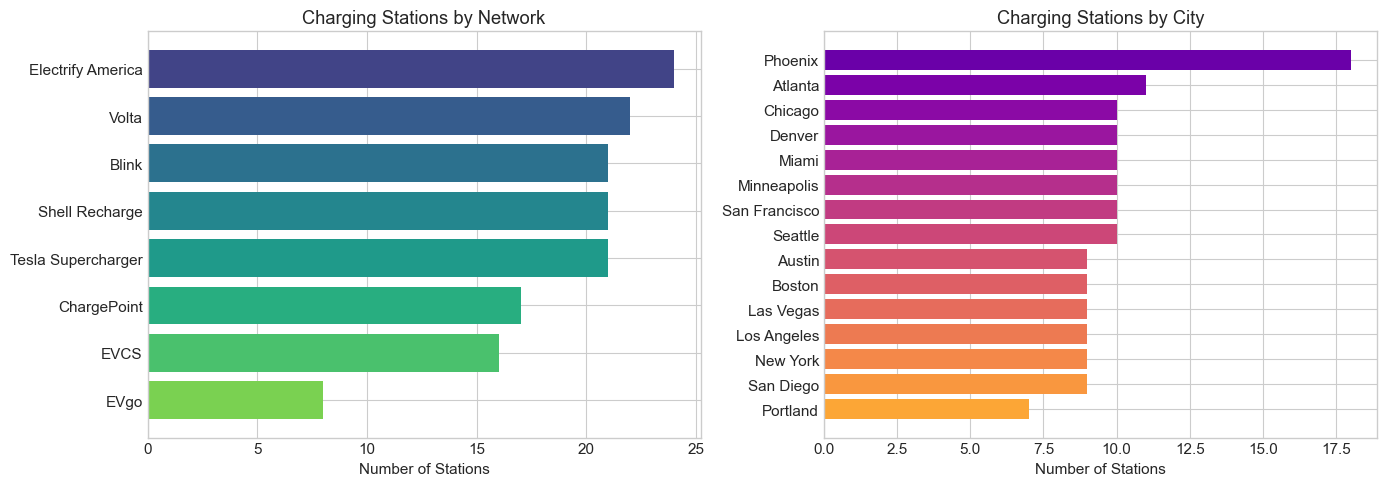

In [11]:
# Number of unique stations per network
stations_per_network = df.groupby('network')['station_id'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(stations_per_network)))
axes[0].barh(stations_per_network.index, stations_per_network.values, color=colors)
axes[0].set_xlabel('Number of Stations')
axes[0].set_title('Charging Stations by Network')
axes[0].invert_yaxis()

# Stations by city
stations_per_city = df.groupby('city')['station_id'].nunique().sort_values(ascending=False)
colors2 = plt.cm.plasma(np.linspace(0.2, 0.8, len(stations_per_city)))
axes[1].barh(stations_per_city.index, stations_per_city.values, color=colors2)
axes[1].set_xlabel('Number of Stations')
axes[1].set_title('Charging Stations by City')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

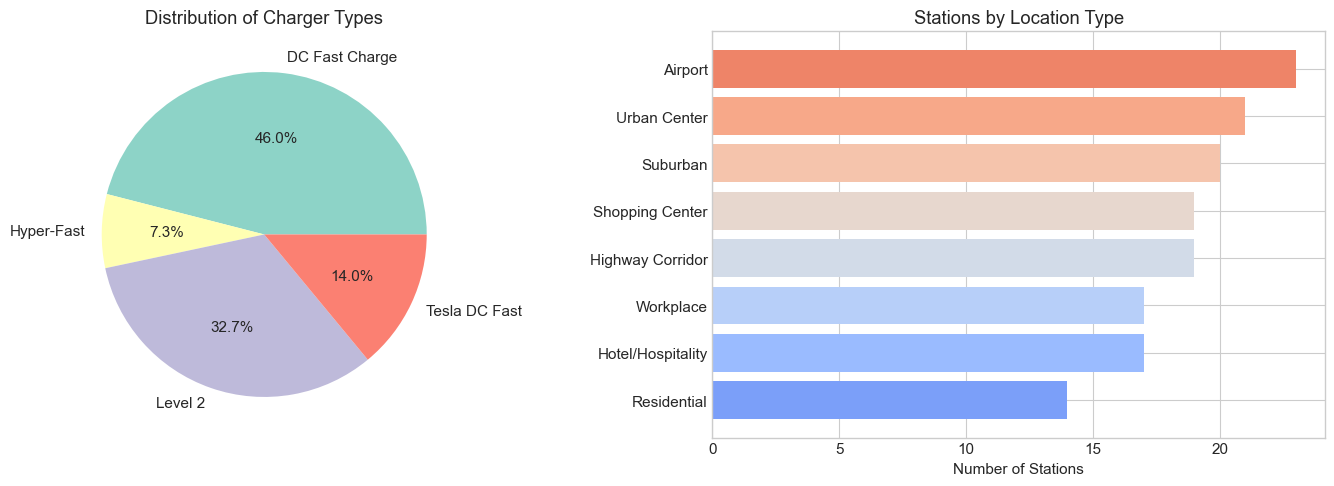

In [12]:
# Charger type distribution
charger_dist = df.groupby('charger_type')['station_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(charger_dist.values, labels=charger_dist.index, autopct='%1.1f%%', 
            colors=plt.cm.Set3.colors[:len(charger_dist)])
axes[0].set_title('Distribution of Charger Types')

# Location type distribution
location_dist = df.groupby('location_type')['station_id'].nunique().sort_values(ascending=True)
axes[1].barh(location_dist.index, location_dist.values, color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(location_dist))))
axes[1].set_xlabel('Number of Stations')
axes[1].set_title('Stations by Location Type')

plt.tight_layout()
plt.show()

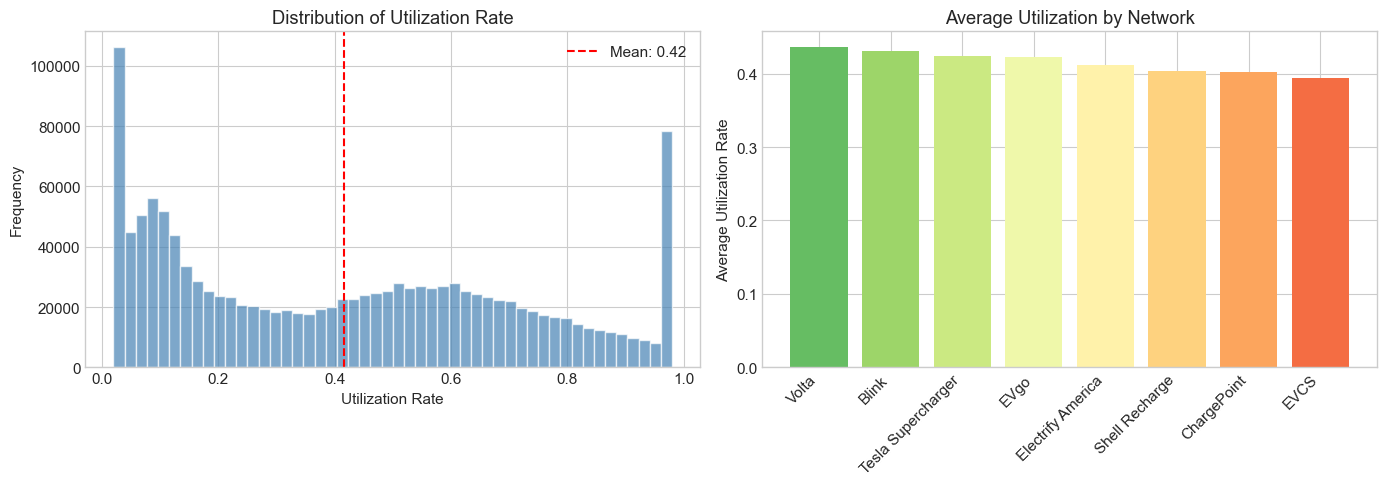

In [13]:
# Utilization rate distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['utilization_rate'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df['utilization_rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["utilization_rate"].mean():.2f}')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Utilization Rate')
axes[0].legend()

# Utilization by network
util_by_network = df.groupby('network')['utilization_rate'].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(util_by_network)))
axes[1].bar(range(len(util_by_network)), util_by_network.values, color=colors)
axes[1].set_xticks(range(len(util_by_network)))
axes[1].set_xticklabels(util_by_network.index, rotation=45, ha='right')
axes[1].set_ylabel('Average Utilization Rate')
axes[1].set_title('Average Utilization by Network')

plt.tight_layout()
plt.show()

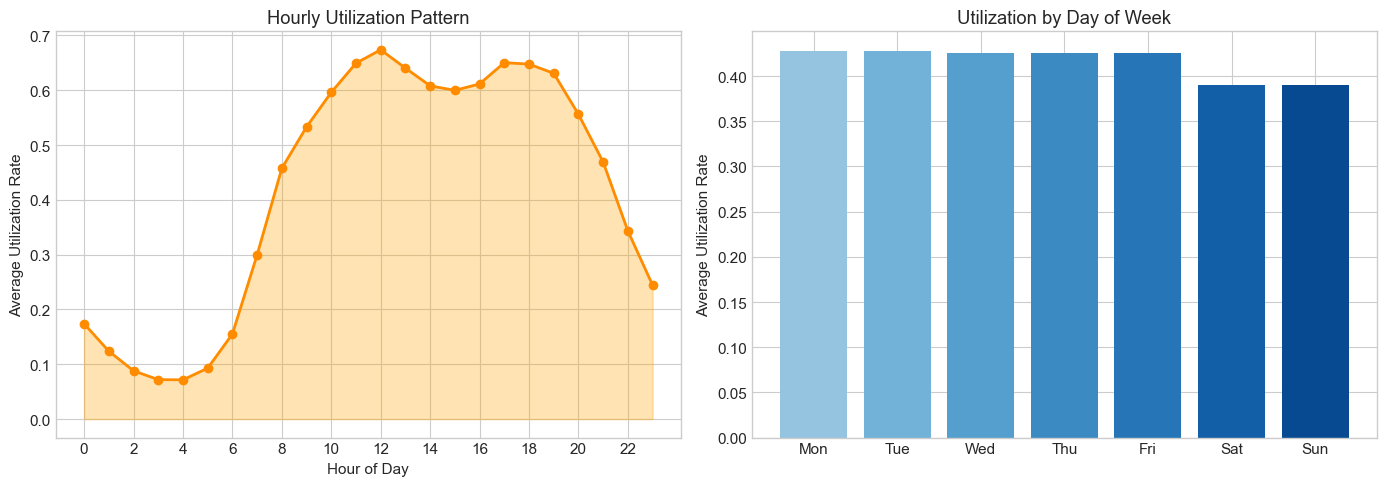

In [15]:
# Hourly utilization pattern
hourly_util = df.groupby('hour_of_day')['utilization_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_util.index, hourly_util.values, marker='o', linewidth=2, markersize=6, color='darkorange')
axes[0].fill_between(hourly_util.index, hourly_util.values, alpha=0.3, color='orange')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Utilization Rate')
axes[0].set_title('Hourly Utilization Pattern')
axes[0].set_xticks(range(0, 24, 2))

# Day of week pattern
dow_util = df.groupby('day_of_week')['utilization_rate'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), dow_util.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, 7)))
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_ylabel('Average Utilization Rate')
axes[1].set_title('Utilization by Day of Week')

plt.tight_layout()
plt.show()

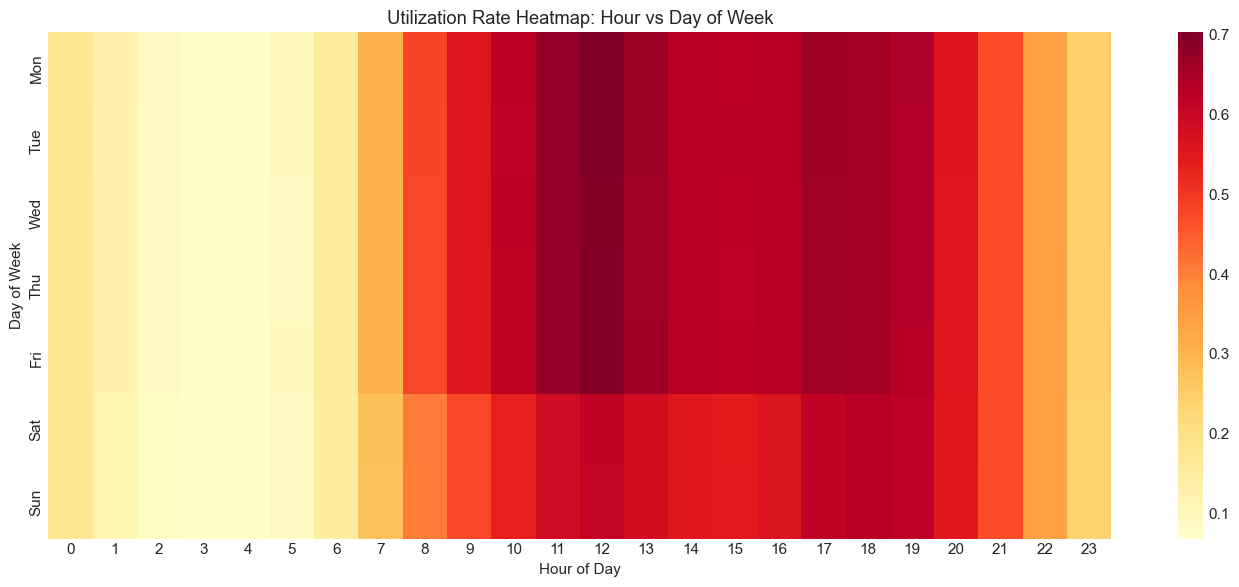

In [17]:
# Heatmap: Hour vs Day of Week
pivot_util = df.pivot_table(values='utilization_rate', index='day_of_week', columns='hour_of_day', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_util, cmap='YlOrRd', annot=False, fmt='.2f', 
            yticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Utilization Rate Heatmap: Hour vs Day of Week')
plt.tight_layout()
plt.show()

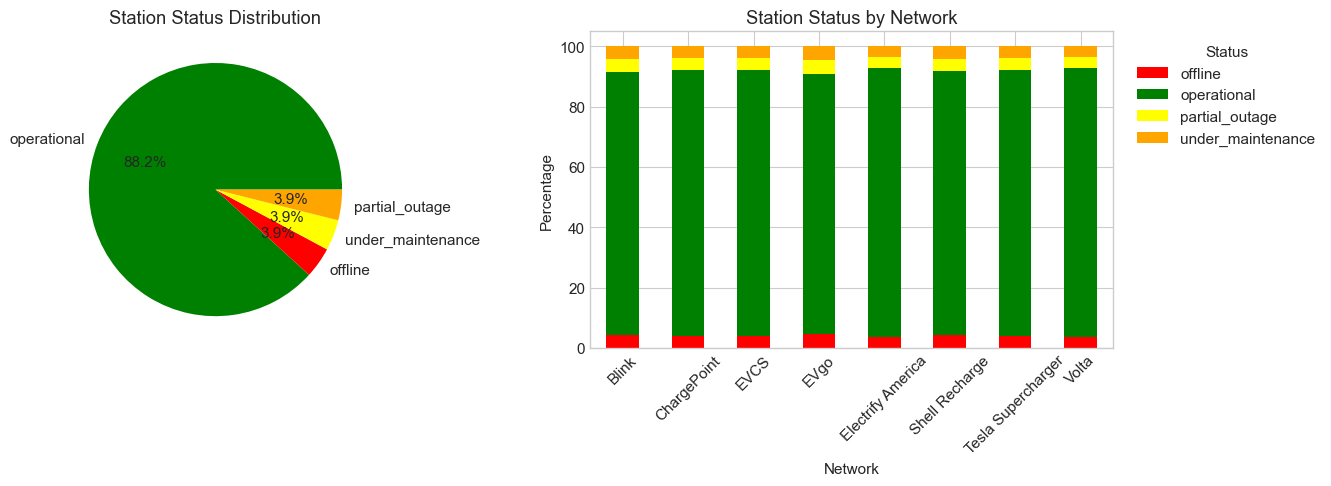

In [18]:
# Station status distribution
status_dist = df['station_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_status = {'operational': 'green', 'partial_outage': 'orange', 'under_maintenance': 'yellow', 'offline': 'red'}
colors_list = [colors_status.get(s, 'gray') for s in status_dist.index]

axes[0].pie(status_dist.values, labels=status_dist.index, autopct='%1.1f%%', colors=colors_list)
axes[0].set_title('Station Status Distribution')

# Status by network
status_network = df.groupby(['network', 'station_status']).size().unstack(fill_value=0)
status_network_pct = status_network.div(status_network.sum(axis=1), axis=0) * 100

status_network_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green', 'yellow', 'orange'])
axes[1].set_xlabel('Network')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Station Status by Network')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

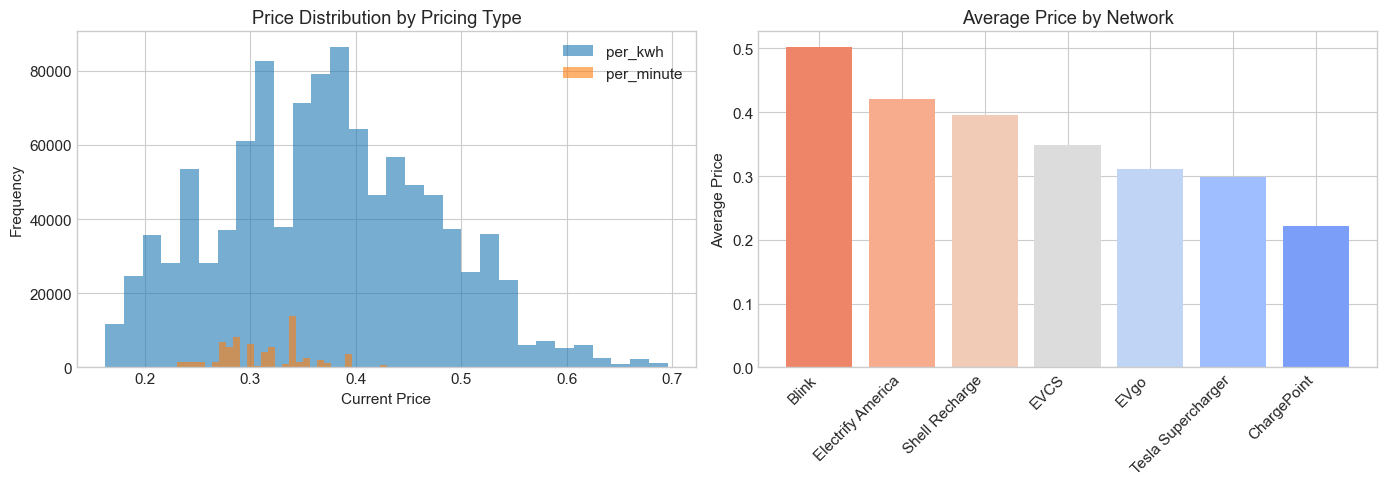

In [19]:
# Price distribution by pricing type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ptype in df['pricing_type'].unique():
    if ptype != 'free':
        subset = df[df['pricing_type'] == ptype]['current_price']
        axes[0].hist(subset, bins=30, alpha=0.6, label=ptype)

axes[0].set_xlabel('Current Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution by Pricing Type')
axes[0].legend()

# Average price by network
price_by_network = df[df['pricing_type'] != 'free'].groupby('network')['current_price'].mean().sort_values(ascending=False)
axes[1].bar(range(len(price_by_network)), price_by_network.values, 
            color=plt.cm.coolwarm(np.linspace(0.8, 0.2, len(price_by_network))))
axes[1].set_xticks(range(len(price_by_network)))
axes[1].set_xticklabels(price_by_network.index, rotation=45, ha='right')
axes[1].set_ylabel('Average Price')
axes[1].set_title('Average Price by Network')

plt.tight_layout()
plt.show()

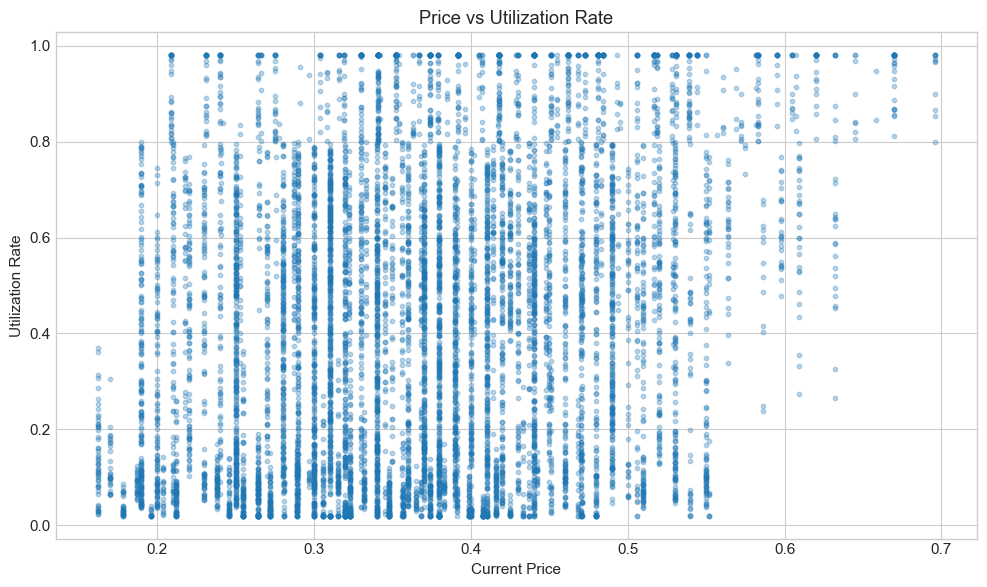

Correlation between price and utilization: 0.2620


In [20]:
# Price vs utilization relationship
paid_df = df[df['pricing_type'] != 'free'].sample(n=min(10000, len(df)))

plt.figure(figsize=(10, 6))
plt.scatter(paid_df['current_price'], paid_df['utilization_rate'], alpha=0.3, s=10)
plt.xlabel('Current Price')
plt.ylabel('Utilization Rate')
plt.title('Price vs Utilization Rate')
plt.tight_layout()
plt.show()

print(f'Correlation between price and utilization: {paid_df["current_price"].corr(paid_df["utilization_rate"]):.4f}')

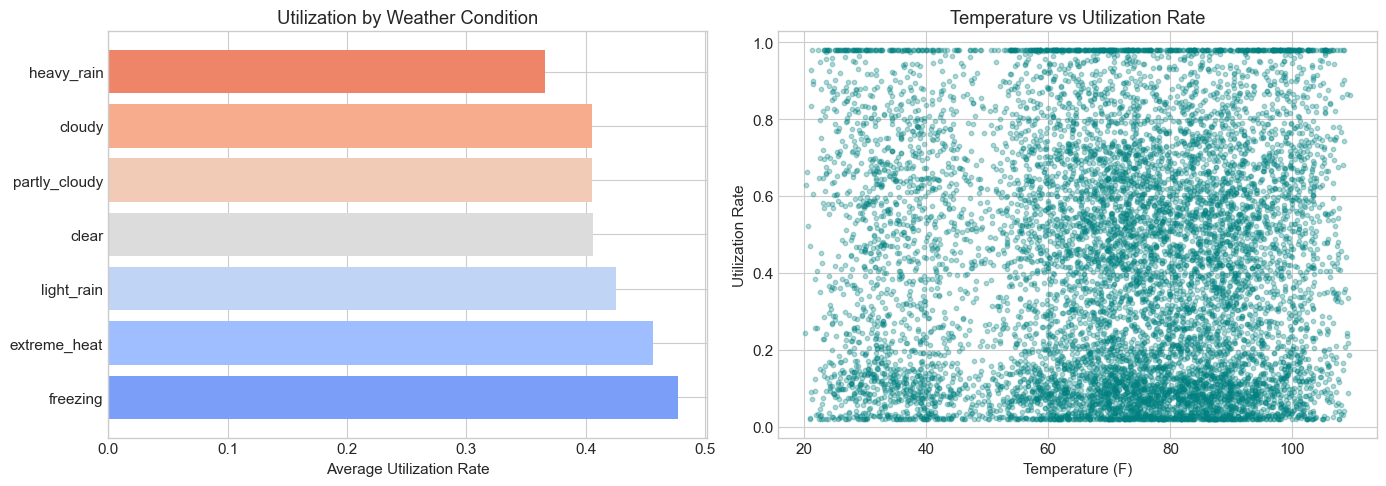

In [21]:
# Utilization by weather condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

util_weather = df.groupby('weather_condition')['utilization_rate'].mean().sort_values(ascending=False)
colors_weather = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(util_weather)))
axes[0].barh(util_weather.index, util_weather.values, color=colors_weather)
axes[0].set_xlabel('Average Utilization Rate')
axes[0].set_title('Utilization by Weather Condition')

# Temperature vs utilization
temp_sample = df.sample(n=min(10000, len(df)))
axes[1].scatter(temp_sample['temperature_f'], temp_sample['utilization_rate'], alpha=0.3, s=10, c='teal')
axes[1].set_xlabel('Temperature (F)')
axes[1].set_ylabel('Utilization Rate')
axes[1].set_title('Temperature vs Utilization Rate')

plt.tight_layout()
plt.show()

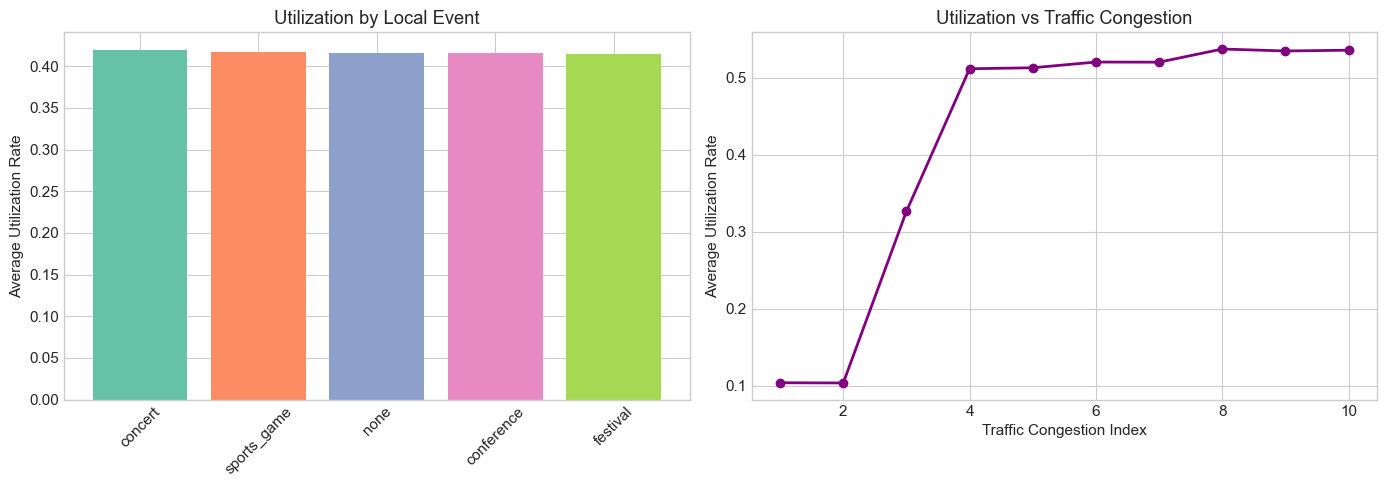

In [22]:
# Impact of local events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_util = df.groupby('local_event')['utilization_rate'].mean().sort_values(ascending=False)
axes[0].bar(event_util.index, event_util.values, color=plt.cm.Set2.colors[:len(event_util)])
axes[0].set_ylabel('Average Utilization Rate')
axes[0].set_title('Utilization by Local Event')
axes[0].tick_params(axis='x', rotation=45)

# Traffic congestion impact
traffic_util = df.groupby('traffic_congestion_index')['utilization_rate'].mean()
axes[1].plot(traffic_util.index, traffic_util.values, marker='o', linewidth=2, color='purple')
axes[1].set_xlabel('Traffic Congestion Index')
axes[1].set_ylabel('Average Utilization Rate')
axes[1].set_title('Utilization vs Traffic Congestion')

plt.tight_layout()
plt.show()

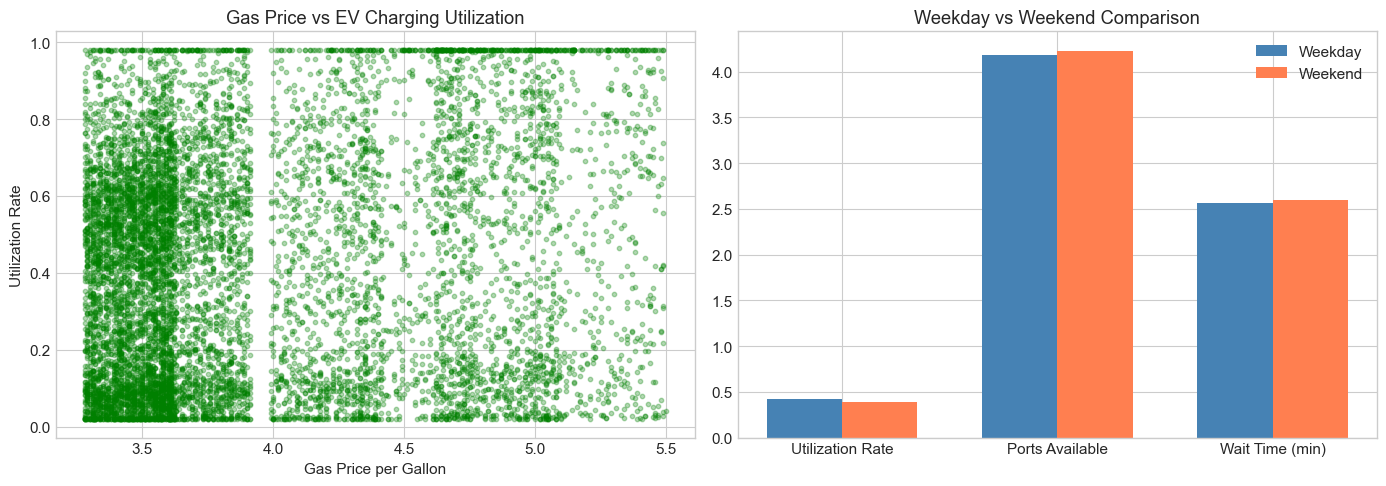

In [23]:
# Gas price correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gas_sample = df.sample(n=min(10000, len(df)))
axes[0].scatter(gas_sample['gas_price_per_gallon'], gas_sample['utilization_rate'], alpha=0.3, s=10, c='green')
axes[0].set_xlabel('Gas Price per Gallon')
axes[0].set_ylabel('Utilization Rate')
axes[0].set_title('Gas Price vs EV Charging Utilization')

# Weekend vs weekday comparison
weekend_data = df.groupby('is_weekend').agg({
    'utilization_rate': 'mean',
    'ports_available': 'mean',
    'estimated_wait_time_mins': 'mean'
}).round(3)
weekend_data.index = ['Weekday', 'Weekend']

x = np.arange(len(weekend_data.columns))
width = 0.35

bars1 = axes[1].bar(x - width/2, weekend_data.iloc[0], width, label='Weekday', color='steelblue')
bars2 = axes[1].bar(x + width/2, weekend_data.iloc[1], width, label='Weekend', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Utilization Rate', 'Ports Available', 'Wait Time (min)'])
axes[1].set_title('Weekday vs Weekend Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

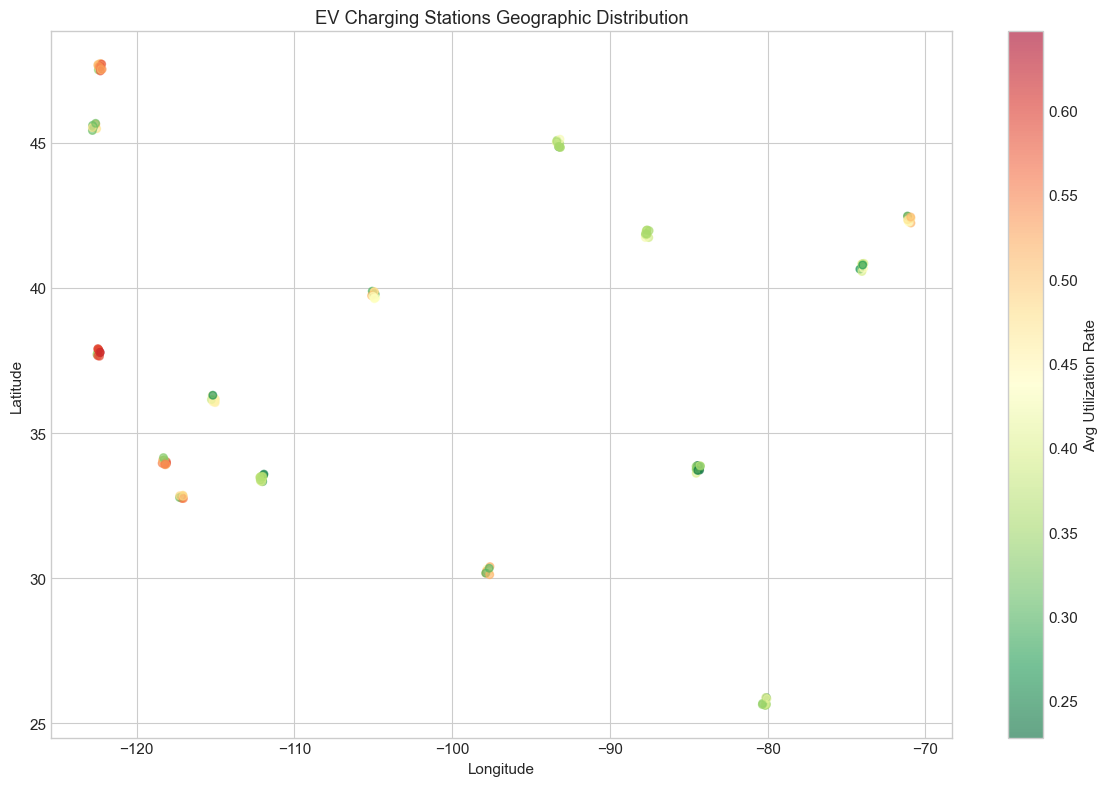

In [24]:
# Station locations scatter plot
station_locations = df.groupby('station_id').agg({
    'latitude': 'first',
    'longitude': 'first',
    'utilization_rate': 'mean',
    'city': 'first'
}).reset_index()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(station_locations['longitude'], station_locations['latitude'],
                      c=station_locations['utilization_rate'], cmap='RdYlGn_r',
                      s=30, alpha=0.6)
plt.colorbar(scatter, label='Avg Utilization Rate')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('EV Charging Stations Geographic Distribution')
plt.tight_layout()
plt.show()

In [25]:
# City-level statistics
city_stats = df.groupby('city').agg({
    'station_id': 'nunique',
    'utilization_rate': 'mean',
    'current_price': 'mean',
    'ports_total': 'mean',
    'estimated_wait_time_mins': 'mean'
}).round(3)
city_stats.columns = ['Stations', 'Avg Utilization', 'Avg Price', 'Avg Ports', 'Avg Wait Time']
city_stats = city_stats.sort_values('Stations', ascending=False)
print('City-Level Statistics:')
city_stats

City-Level Statistics:


,Stations,Avg Utilization,Avg Price,Avg Ports,Avg Wait Time
city,,,,,
Phoenix,18,0.359,0.354,6.444,1.616
Atlanta,11,0.315,0.327,9.091,1.590
Chicago,10,0.378,0.376,5.000,3.052
Denver,10,0.414,0.293,8.000,3.307
Miami,10,0.358,0.261,8.600,2.873
Minneapolis,10,0.363,0.322,7.000,1.299
San Francisco,10,0.548,0.307,8.400,2.757
Seattle,10,0.520,0.367,6.600,2.697
Austin,9,0.446,0.304,8.889,2.454


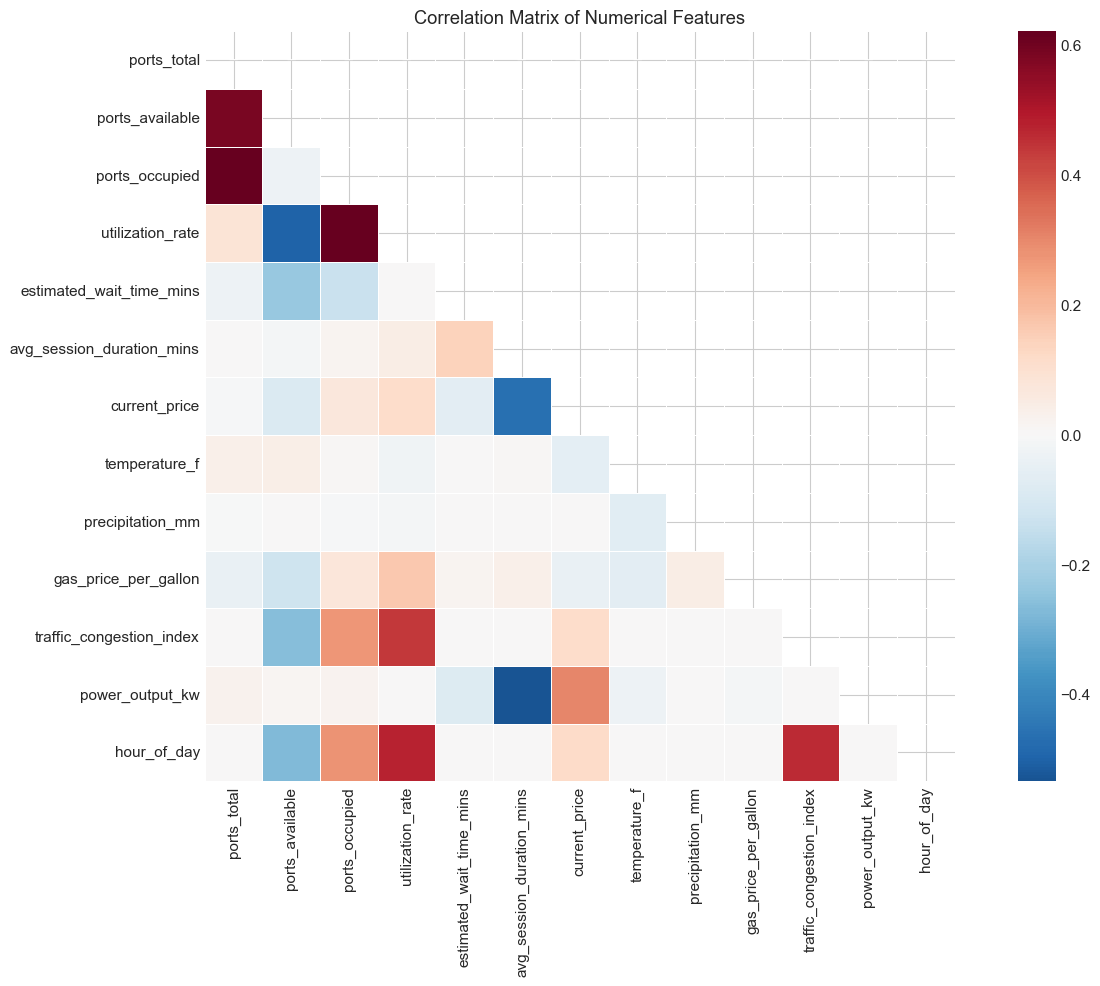

In [26]:
# Correlation matrix for numerical features
num_cols = ['ports_total', 'ports_available', 'ports_occupied', 'utilization_rate',
            'estimated_wait_time_mins', 'avg_session_duration_mins', 'current_price',
            'temperature_f', 'precipitation_mm', 'gas_price_per_gallon', 
            'traffic_congestion_index', 'power_output_kw', 'hour_of_day']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

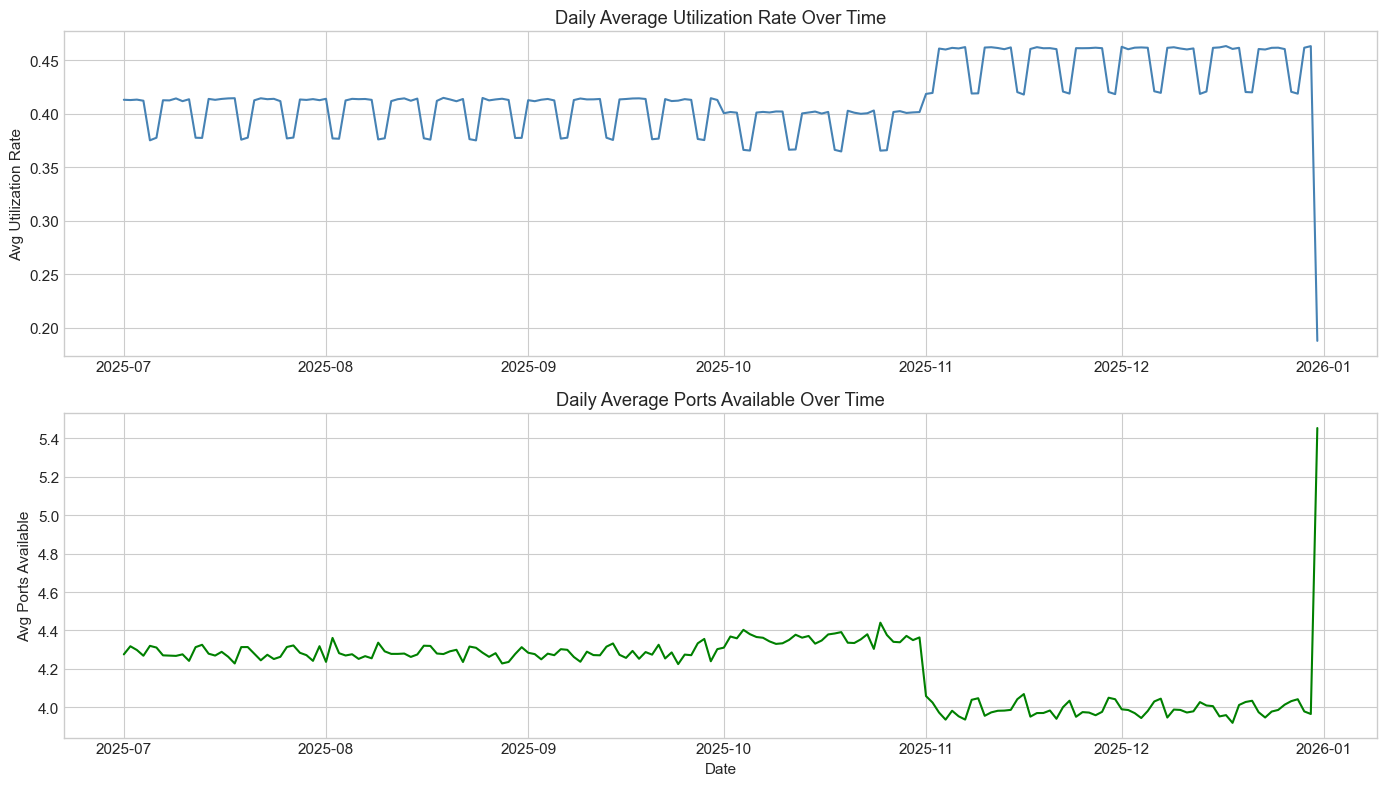

In [27]:
# Daily utilization trend
daily_util = df.groupby(df['timestamp'].dt.date).agg({
    'utilization_rate': 'mean',
    'ports_available': 'mean'
})

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_util.index, daily_util['utilization_rate'], linewidth=1.5, color='steelblue')
axes[0].set_ylabel('Avg Utilization Rate')
axes[0].set_title('Daily Average Utilization Rate Over Time')

axes[1].plot(daily_util.index, daily_util['ports_available'], linewidth=1.5, color='green')
axes[1].set_ylabel('Avg Ports Available')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily Average Ports Available Over Time')

plt.tight_layout()
plt.show()

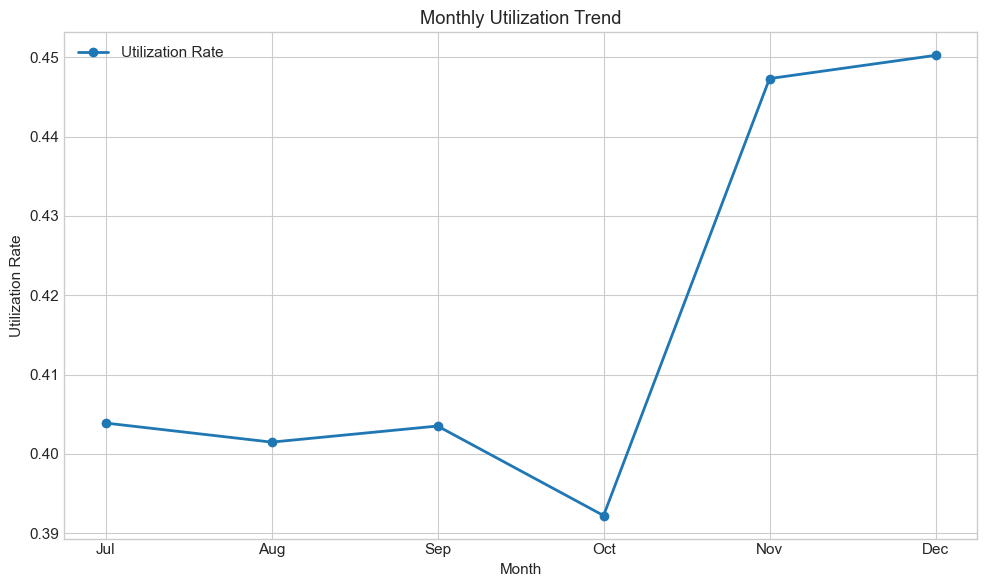

In [28]:
# Monthly trends
monthly_stats = df.groupby('month').agg({
    'utilization_rate': 'mean',
    'current_price': 'mean',
    'estimated_wait_time_mins': 'mean'
})

fig, ax = plt.subplots(figsize=(10, 6))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
available_months = [months[m-1] for m in monthly_stats.index]

ax.plot(available_months, monthly_stats['utilization_rate'], marker='o', linewidth=2, label='Utilization Rate')
ax.set_ylabel('Utilization Rate')
ax.set_xlabel('Month')
ax.set_title('Monthly Utilization Trend')
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
# Summary statistics
print('KEY DATASET INSIGHTS')
print('=' * 50)
print(f'Total Records: {len(df):,}')
print(f'Unique Stations: {df["station_id"].nunique():,}')
print(f'Networks: {df["network"].nunique()}')
print(f'Cities: {df["city"].nunique()}')
print(f'Date Range: {df["timestamp"].min().date()} to {df["timestamp"].max().date()}')
print()
print('UTILIZATION METRICS')
print('-' * 50)
print(f'Average Utilization Rate: {df["utilization_rate"].mean():.3f}')
print(f'Peak Hour Utilization: {df[df["is_peak_hour"] == True]["utilization_rate"].mean():.3f}')
print(f'Off-Peak Utilization: {df[df["is_peak_hour"] == False]["utilization_rate"].mean():.3f}')
print()
print('OPERATIONAL METRICS')
print('-' * 50)
print(f'Operational Rate: {(df["station_status"] == "operational").mean()*100:.1f} percent')
print(f'Average Wait Time: {df["estimated_wait_time_mins"].mean():.1f} minutes')
print(f'Average Session Duration: {df["avg_session_duration_mins"].mean():.1f} minutes')

KEY DATASET INSIGHTS
Total Records: 1,317,750
Unique Stations: 150
Networks: 8
Cities: 15
Date Range: 2025-07-01 to 2025-12-31

UTILIZATION METRICS
--------------------------------------------------
Average Utilization Rate: 0.416
Peak Hour Utilization: 0.539
Off-Peak Utilization: 0.365

OPERATIONAL METRICS
--------------------------------------------------
Operational Rate: 88.2 percent
Average Wait Time: 2.6 minutes
Average Session Duration: 81.9 minutes


In [30]:
# Top performing networks
network_perf = df.groupby('network').agg({
    'utilization_rate': 'mean',
    'station_id': 'nunique',
    'ports_total': 'mean'
}).round(3)
network_perf.columns = ['Avg Utilization', 'Stations', 'Avg Ports']
print('\nNetwork Performance Summary:')
network_perf.sort_values('Avg Utilization', ascending=False)


Network Performance Summary:


,Avg Utilization,Stations,Avg Ports
network,,,
Volta,0.436,22,6.909
Blink,0.430,21,6.952
Tesla Supercharger,0.424,21,10.190
EVgo,0.422,8,10.000
Electrify America,0.412,24,5.833
Shell Recharge,0.404,21,7.238
ChargePoint,0.402,17,6.471
EVCS,0.394,16,6.375


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


target = "utilization_rate"

drop_cols = [
    "ports_occupied",
    "ports_available",
    "estimated_wait_time_mins",
    "station_id",
    "station_name",
    "timestamp",
    target,
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
y = df[target].copy()

# Numeric-only fast baseline model
X_num = X.select_dtypes(include=[np.number]).copy()

N = 250_000
idx = df.sample(n=N, random_state=42).index
X_s = X_num.loc[idx].reset_index(drop=True)
y_s = y.loc[idx].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-4,
    random_state=42
)

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", sgd)
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)

print(f"Target: {target}")
print(f"Rows used: {N:,} | Numeric features: {X_s.shape[1]}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R^2  = {r2:.4f}")


Target: utilization_rate
Rows used: 250,000 | Numeric features: 14
MAE  = 0.1983
RMSE = 0.2455
R^2  = 0.3280


In [7]:
# Feature importance via absolute standardized coefficients (since we scaled features)
feature_names = X_s.columns.tolist()
coefs = pipe.named_steps["model"].coef_
importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

importance.head(10)

,feature,coef,abs_coef
11,hour_of_day,0.101506,0.101506
10,traffic_congestion_index,0.079835,0.079835
9,gas_price_per_gallon,0.042895,0.042895
5,avg_session_duration_mins,0.028429,0.028429
3,ports_total,0.025843,0.025843
6,current_price,0.025282,0.025282
1,longitude,-0.016626,0.016626
12,day_of_week,-0.014996,0.014996
0,latitude,0.010681,0.010681
13,month,0.009461,0.009461


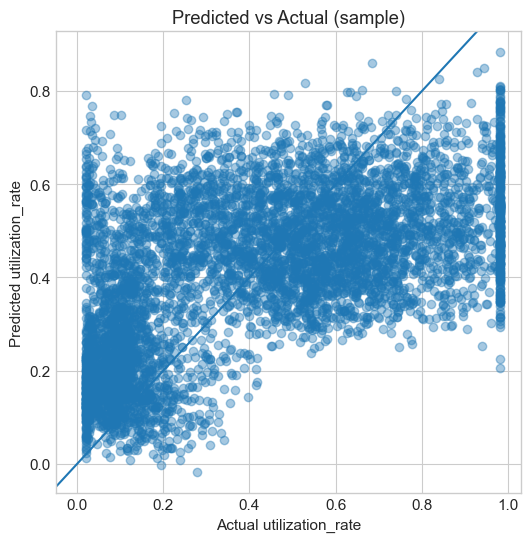

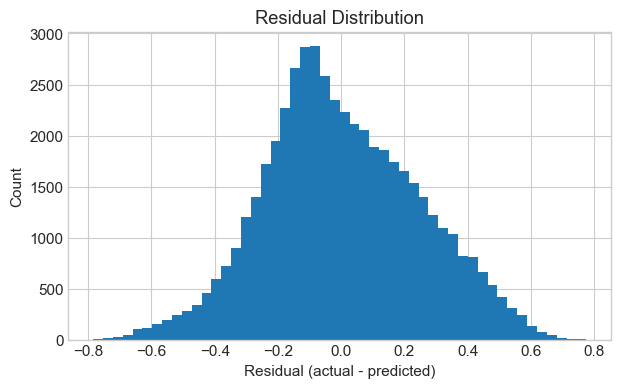

,feature,coef,abs_coef
11,hour_of_day,0.101506,0.101506
10,traffic_congestion_index,0.079835,0.079835
9,gas_price_per_gallon,0.042895,0.042895
5,avg_session_duration_mins,0.028429,0.028429
3,ports_total,0.025843,0.025843
6,current_price,0.025282,0.025282
1,longitude,-0.016626,0.016626
12,day_of_week,-0.014996,0.014996
0,latitude,0.010681,0.010681
13,month,0.009461,0.009461


In [8]:
# Predicted vs actual plot (sample for readability)
sample_n = 6000
s_idx = np.random.RandomState(42).choice(len(y_test), size=sample_n, replace=False)

plt.figure(figsize=(6,6))
plt.scatter(np.array(y_test)[s_idx], np.array(pred)[s_idx], alpha=0.4)
plt.xlabel("Actual utilization_rate")
plt.ylabel("Predicted utilization_rate")
plt.title("Predicted vs Actual (sample)")
plt.axline((0, 0), slope=1)
plt.show()

# Residual distribution
resid = np.array(y_test) - np.array(pred)
plt.figure(figsize=(7,4))
plt.hist(resid, bins=50)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

# Show top coefficients table
importance.head(15)


In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


target = "utilization_rate"

# Remove leakage + IDs
drop_cols = [
    "ports_occupied",
    "ports_available",
    "estimated_wait_time_mins",
    "station_id",
    "station_name",
    "timestamp",
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Keep numeric + charger_type + network
keep_cols = list(df_model.select_dtypes(include=[np.number]).columns)
for col in ["charger_type", "network"]:
    if col in df_model.columns:
        keep_cols.append(col)

df_model = df_model[keep_cols]

X = df_model.drop(columns=[target])
y = df_model[target]

# Sample for performance
N = 120_000
idx = df_model.sample(n=N, random_state=42).index
X_s = X.loc[idx].reset_index(drop=True)
y_s = y.loc[idx].reset_index(drop=True)

# Separate feature types
numeric_features = X_s.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_s.columns if c not in numeric_features]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-4,
    random_state=42
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)

print(f"Rows used: {N:,}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R^2  = {r2:.4f}")

# Extract feature names after encoding
feature_names = (
    numeric_features +
    list(pipe.named_steps["preprocess"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(categorical_features))
)

coefs = pipe.named_steps["model"].coef_

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

importance.head(20)


Rows used: 120,000
MAE  = 0.1907
RMSE = 0.2356
R^2  = 0.3785


,feature,coef,abs_coef
23,network_Volta,0.559222,0.559222
17,network_ChargePoint,0.291837,0.291837
6,current_price,0.194200,0.194200
19,network_EVgo,0.181993,0.181993
18,network_EVCS,0.138698,0.138698
22,network_Tesla Supercharger,0.098779,0.098779
16,charger_type_Tesla DC Fast,0.098779,0.098779
11,hour_of_day,0.090411,0.090411
21,network_Shell Recharge,0.067863,0.067863
20,network_Electrify America,0.067854,0.067854
